In [1]:
import os
from pathlib import Path
cwd = Path.cwd()

if cwd.name == "notebooks":
    os.chdir(cwd.parent)

In [2]:
import os, math, json
from pathlib import Path
import numpy as np
import torch
import pandas as pd

import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.spatial.distance import jensenshannon

In [ ]:
RESULTS_PATH = "data/experiments/whole_img_cls_patching/vitbase_neutrality/group_patching_results.pt"  # <- change me

res = torch.load(RESULTS_PATH, map_location="cpu", weights_only=False)
print(res.keys())
print("has original:", "original" in res, "| has patched:", "patched" in res)

print("streams in layer_0:", list(res["patched"]["layer_1"].keys()))
first_stream = list(res["patched"]["layer_1"].keys())[0]
first_combo = list(res["patched"]["layer_1"][first_stream].keys())[0]
print("example combo:", first_combo)
print("keys inside combo:", res["patched"]["layer_1"][first_stream][first_combo].keys())


dict_keys(['original', 'corrupted', 'patched', 'emotion_map', 'groups_json_path', 'file_key', 'groups', 'combo_names'])
has original: True | has patched: True
streams in layer_0: ['block_output', 'attention_output', 'mlp_activation']
example combo: full_face
keys inside combo: dict_keys(['patched_groups', 'patched_patch_indices', 'final_probs', 'probe_next_layer_probs'])


In [4]:
res["patched"]["layer_1"][first_stream][first_combo]['probe_next_layer_probs']

array([[8.18092232e-02, 1.10902462e-07, 9.14354235e-01, 3.82456094e-03,
        9.91874882e-07, 1.08781560e-05]])

In [ ]:
EPS = 1e-12

def to_np_probs(x):
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    if x.ndim == 2 and x.shape[0] == 1:
        x = x[0]
    assert x.ndim == 1, f"expected [C], got {x.shape}"
    x = np.clip(x, EPS, 1.0)
    x = x / x.sum()
    return x

def kl_div(p, q):
    """KL(p || q)"""
    p = np.clip(p, EPS, 1.0); p = p / p.sum()
    q = np.clip(q, EPS, 1.0); q = q / q.sum()
    return float(np.sum(p * (np.log(p) - np.log(q))))

def js_div(p, q):
    """Jensen-Shannon divergence (base e)."""
    p = np.clip(p, EPS, 1.0); p = p / p.sum()
    q = np.clip(q, EPS, 1.0); q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5 * kl_div(p, m) + 0.5 * kl_div(q, m)

def l1_dist(p, q):
    return float(np.sum(np.abs(p - q)))

def entropy(p):
    p = np.clip(p, EPS, 1.0); p = p / p.sum()
    return float(-np.sum(p * np.log(p)))

def top1(p):
    return int(np.argmax(p))

def delta_p_correct(p_base, p_new, correct_idx):
    return float(p_new[correct_idx] - p_base[correct_idx])

def delta_p_pred(p_base, p_new):
    pred = top1(p_base)
    return float(p_new[pred] - p_base[pred])

def flip(base_probs, new_probs):
    return top1(base_probs) != top1(new_probs)


In [6]:
orig_final = to_np_probs(res["original"]["final_probs"])
corr_final = to_np_probs(res["corrupted"]["final_probs"])

correct_idx = None
md = res["original"].get("metadata", {})
if isinstance(md, dict):
    val = md['emotion']
    if isinstance(val, str) and "emotion_map" in res:
        rev = {v[0]:k for k,v in res["emotion_map"].items()}
        if val in rev:
            correct_idx = int(rev[val])

if correct_idx is None:
    correct_idx = int(np.argmax(orig_final))
    print("WARNING: correct_idx not found in metadata. Using baseline top-1 as 'correct' =", correct_idx)
else:
    print("correct_idx from metadata =", correct_idx)

print("orig top1:", np.argmax(orig_final), "corr top1:", np.argmax(corr_final), "correct_idx:", correct_idx)


correct_idx from metadata = 1
orig top1: 1 corr top1: 2 correct_idx: 1


In [7]:
res["emotion_map"]

{0: 'neutrality',
 1: 'happiness',
 2: 'sadness',
 3: 'anger',
 4: 'disgust',
 5: 'fear'}

In [8]:
rows = []

base = orig_final

for layer_key, layer_dict in tqdm(res["patched"].items()):
    layer_idx = int(layer_key.split("_")[1])
    for stream, combos in layer_dict.items():
        for combo_name, payload in combos.items():
            p_final = to_np_probs(payload.get("final_probs"))
            p_probe = to_np_probs(payload.get("probe_next_layer_probs"))

            row = {
                "layer": layer_idx,
                "stream": stream,
                "combo": combo_name,
                "n_patches": len(payload.get("patched_patch_indices", [])),
                "final_top1": top1(p_final),
                "final_flip": flip(base, p_final),
                "delta_p_correct": delta_p_correct(base, p_final, correct_idx),
                "delta_p_pred": delta_p_pred(base, p_final),
                "KL_base_to_patched": kl_div(base, p_final),
                "KL_patched_to_base": kl_div(p_final, base),
                "JS": js_div(base, p_final),
                "L1": l1_dist(base, p_final),
                "H_base": entropy(base),
                "H_patched": entropy(p_final),
                "delta_entropy": entropy(p_final) - entropy(base),
            }

            if p_probe is not None:
                row.update({
                    "probe_top1": top1(p_probe),
                    "probe_flip_vs_base": flip(base, p_probe),
                    "probe_delta_p_correct": delta_p_correct(base, p_probe, correct_idx),
                    "probe_JS": js_div(base, p_probe),
                    "probe_L1": l1_dist(base, p_probe),
                })
            else:
                row.update({
                    "probe_top1": None,
                    "probe_flip_vs_base": None,
                    "probe_delta_p_correct": None,
                    "probe_JS": None,
                    "probe_L1": None,
                })

            rows.append(row)

df = pd.DataFrame(rows)
print(df.shape)
df.head()



100%|██████████| 12/12 [00:00<00:00, 1648.81it/s]

(36, 20)


,layer,stream,combo,n_patches,final_top1,final_flip,delta_p_correct,delta_p_pred,KL_base_to_patched,KL_patched_to_base,JS,L1,H_base,H_patched,delta_entropy,probe_top1,probe_flip_vs_base,probe_delta_p_correct,probe_JS,probe_L1
0,0,block_output,full_face,197,2,True,-1.000000,-1.000000,27.631021,27.629728,0.693147,2.000000,9.642096e-08,0.001293,0.001293,0.0,True,-0.926351,0.558944,1.852702
1,0,attention_output,full_face,197,2,True,-0.981622,-0.981622,3.996627,26.705620,0.647150,1.963245,9.642096e-08,0.370256,0.370256,0.0,True,-0.995435,0.678559,1.990870
2,0,mlp_activation,full_face,197,2,True,-1.000000,-1.000000,27.631021,27.614388,0.693147,2.000000,9.642096e-08,0.016633,0.016633,0.0,True,-0.902942,0.529145,1.805884
3,1,block_output,full_face,197,2,True,-1.000000,-1.000000,27.631021,27.629728,0.693147,2.000000,9.642096e-08,0.001293,0.001293,2.0,True,-1.000000,0.693146,2.000000
4,1,attention_output,full_face,197,1,False,-0.000103,-0.000103,0.000103,0.001133,0.000036,0.000206,9.642096e-08,0.001124,0.001124,0.0,True,-1.000000,0.693147,2.000000


In [9]:
def show_top(df, metric, n=15, ascending=True):
    display(df.sort_values(metric, ascending=ascending).head(n)[
        ["layer","stream","combo","n_patches", metric, "final_top1", "final_flip"]
    ])

print("Top combos by MOST NEGATIVE delta_p_correct (bigger harm => more negative):")
show_top(df, "delta_p_correct", n=15, ascending=True)

print("\nTop combos by largest JS divergence:")
show_top(df, "JS", n=15, ascending=False)

print("\nFlip rate by combo (aggregated over layer+stream):")
flip_tbl = (
    df.groupby("combo")["final_flip"].mean()
      .sort_values(ascending=False)
      .reset_index()
      .rename(columns={"final_flip":"flip_rate"})
)
display(flip_tbl.head(40))


Top combos by MOST NEGATIVE delta_p_correct (bigger harm => more negative):


,layer,stream,combo,n_patches,delta_p_correct,final_top1,final_flip
0,0,block_output,full_face,197,-1.000000,2,True
2,0,mlp_activation,full_face,197,-1.000000,2,True
3,1,block_output,full_face,197,-1.000000,2,True
6,2,block_output,full_face,197,-1.000000,2,True
12,4,block_output,full_face,197,-1.000000,2,True
15,5,block_output,full_face,197,-1.000000,2,True
9,3,block_output,full_face,197,-1.000000,2,True
18,6,block_output,full_face,197,-1.000000,2,True
24,8,block_output,full_face,197,-1.000000,2,True
27,9,block_output,full_face,197,-1.000000,2,True



Top combos by largest JS divergence:


,layer,stream,combo,n_patches,JS,final_top1,final_flip
0,0,block_output,full_face,197,0.693147,2,True
3,1,block_output,full_face,197,0.693147,2,True
9,3,block_output,full_face,197,0.693147,2,True
6,2,block_output,full_face,197,0.693147,2,True
30,10,block_output,full_face,197,0.693147,2,True
33,11,block_output,full_face,197,0.693147,2,True
15,5,block_output,full_face,197,0.693147,2,True
12,4,block_output,full_face,197,0.693147,2,True
18,6,block_output,full_face,197,0.693147,2,True
27,9,block_output,full_face,197,0.693147,2,True



Flip rate by combo (aggregated over layer+stream):


,combo,flip_rate
0,full_face,0.472222


In [10]:
def heatmap_layer_combo(df_sub, metric, title=None):
    pivot = df_sub.pivot_table(index="combo", columns="layer", values=metric, aggfunc="mean")

    plt.figure(figsize=(12, max(4, 0.35 * len(pivot.index))))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label=metric)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
    plt.xlabel("Layer")
    plt.ylabel("Combo")
    plt.title(title or f"Heatmap: {metric}")
    plt.tight_layout()
    plt.show()
    return pivot


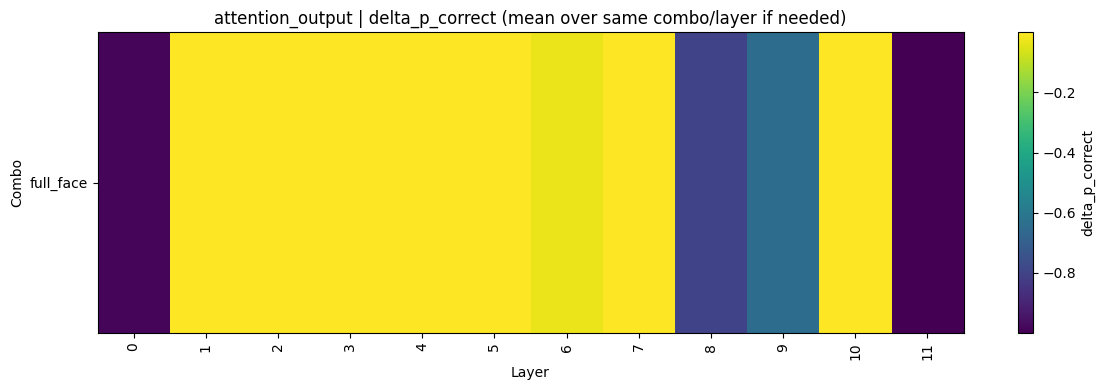

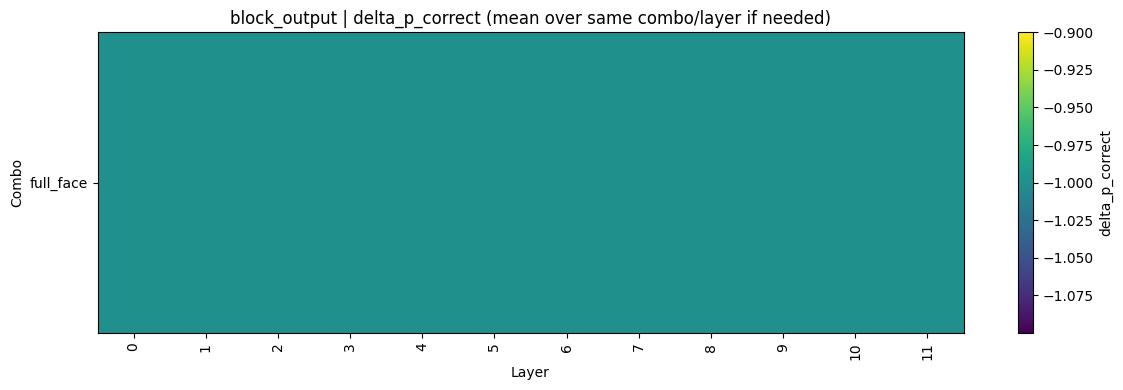

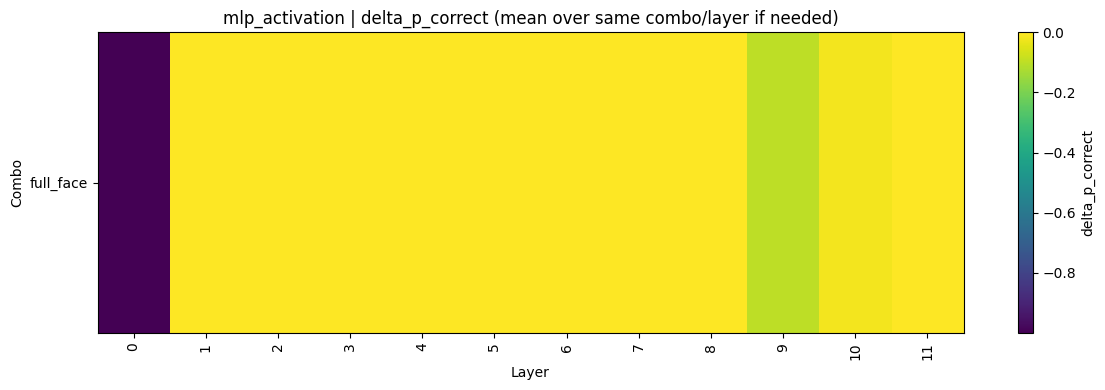

In [11]:
METRICS = ["delta_p_correct"]

for stream in sorted(df["stream"].unique()):
    df_s = df[df["stream"] == stream].copy()

    for m in METRICS:
        heatmap_layer_combo(
            df_s, m,
            title=f"{stream} | {m} (mean over same combo/layer if needed)"
        )


In [ ]:
def best_layer_per_combo(df_sub, metric, mode="min"):
    out = []
    for combo, g in df_sub.groupby("combo"):
        if mode == "min":
            idx = g[metric].idxmin()
        else:
            idx = g[metric].idxmax()
        row = g.loc[idx, ["combo","layer","stream",metric,"n_patches","final_top1","final_flip"]].to_dict()
        out.append(row)
    return pd.DataFrame(out).sort_values(metric, ascending=(mode=="min"))

best_delta = best_layer_per_combo(df, "delta_p_correct", mode="min")
display(best_delta.head(20))



,combo,layer,stream,delta_p_correct,n_patches,final_top1,final_flip
0,full_face,0,block_output,-1.0,197,2,True


Top combos: ['full_face']


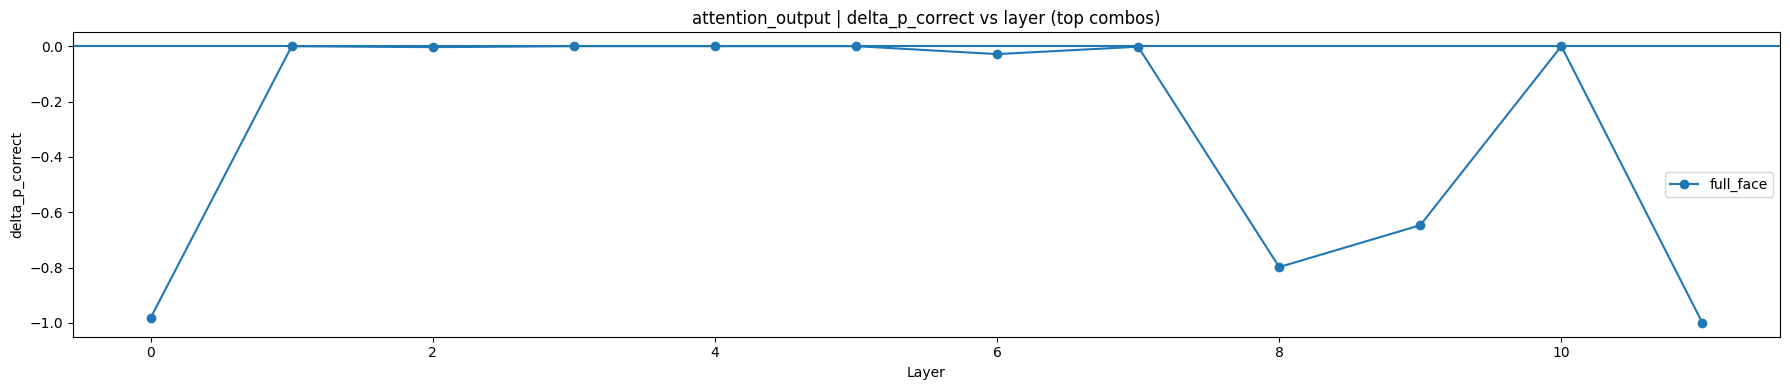

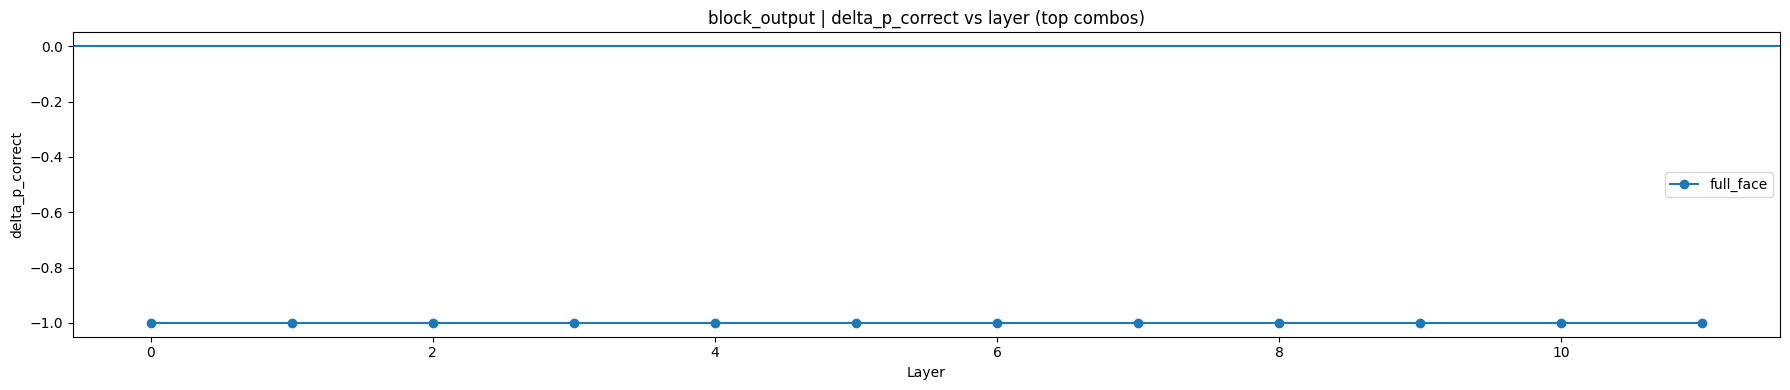

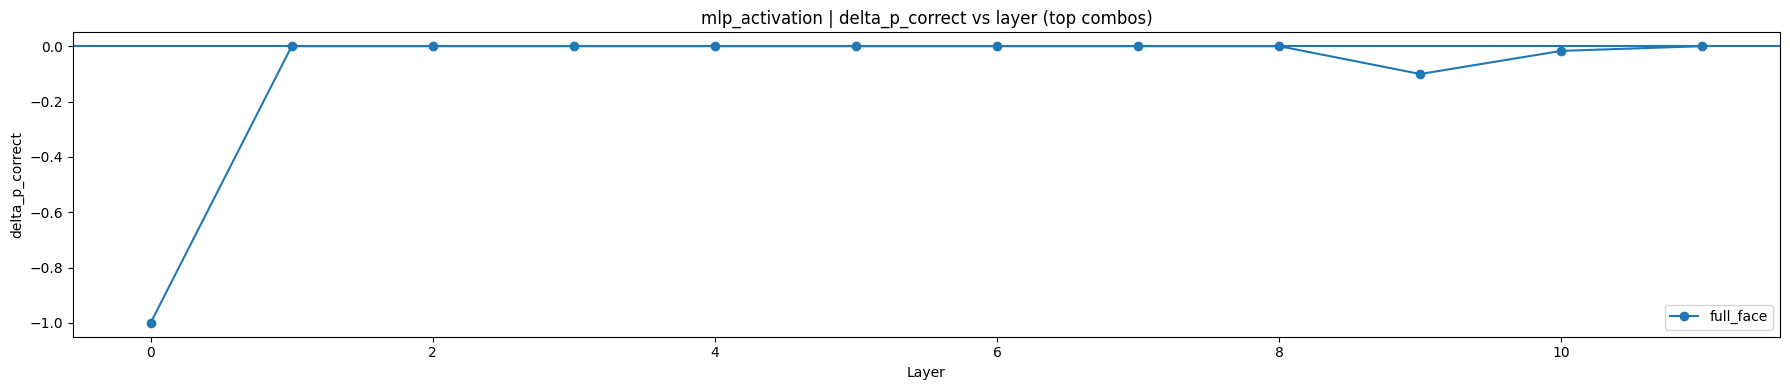

In [13]:
TOPK = 15

top_combos = (
    df.groupby("combo")["delta_p_correct"].min()
      .sort_values()
      .head(TOPK)
      .index
      .tolist()
)
print("Top combos:", top_combos)

metric = "delta_p_correct"  # try "JS", "L1"
for stream in sorted(df["stream"].unique()):
    plt.figure(figsize=(18,4))
    for combo in top_combos:
        g = df[(df["combo"]==combo) & (df["stream"]==stream)].sort_values("layer")
        plt.plot(g["layer"], g[metric], marker="o", label=combo)
    plt.axhline(0.0)
    plt.title(f"{stream} | {metric} vs layer (top combos)")
    plt.xlabel("Layer")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [14]:
agg = (
    df.groupby(["stream","combo"])
      .agg(
          worst_delta=("delta_p_correct","min"),   # most negative
          max_JS=("JS","max"),
          max_L1=("L1","max"),
          flip_rate=("final_flip","mean"),
          n_patches=("n_patches","max"),
      )
      .reset_index()
)

display(agg.sort_values("worst_delta").head(20))
display(agg.sort_values("max_JS", ascending=False).head(20))


,stream,combo,worst_delta,max_JS,max_L1,flip_rate,n_patches
1,block_output,full_face,-1.000000,0.693147,2.000000,1.000000,197
2,mlp_activation,full_face,-1.000000,0.693147,2.000000,0.083333,197
0,attention_output,full_face,-0.999722,0.691870,1.999444,0.333333,197


,stream,combo,worst_delta,max_JS,max_L1,flip_rate,n_patches
1,block_output,full_face,-1.000000,0.693147,2.000000,1.000000,197
2,mlp_activation,full_face,-1.000000,0.693147,2.000000,0.083333,197
0,attention_output,full_face,-0.999722,0.691870,1.999444,0.333333,197


In [15]:
C = len(base)
base_top = int(np.argmax(base))

combo_shift_rows = []
for (stream, combo), g in df.groupby(["stream","combo"]):
    top_counts = g["final_top1"].value_counts()
    most_common_top = int(top_counts.index[0])
    frac = float(top_counts.iloc[0] / top_counts.sum())

    worst_row = g.loc[g["delta_p_correct"].idxmin()]
    combo_shift_rows.append({
        "stream": stream,
        "combo": combo,
        "n_patches": int(worst_row["n_patches"]),
        "baseline_top": base_top,
        "most_common_patched_top": most_common_top,
        "most_common_frac": frac,
        "worst_delta_p_correct": float(worst_row["delta_p_correct"]),
        "flip_rate": float(g["final_flip"].mean()),
    })

combo_shift = pd.DataFrame(combo_shift_rows)
display(combo_shift.sort_values(["worst_delta_p_correct"]).head(30))


,stream,combo,n_patches,baseline_top,most_common_patched_top,most_common_frac,worst_delta_p_correct,flip_rate
1,block_output,full_face,197,1,2,1.000000,-1.000000,1.000000
2,mlp_activation,full_face,197,1,1,0.916667,-1.000000,0.083333
0,attention_output,full_face,197,1,1,0.666667,-0.999722,0.333333
